# Grouping photos by what is in them

**Solution notebook.** Two thousand photographs, no labels, no captions, no filenames worth
reading. The task is the one your phone does silently: **put the photos that show the same kind
of thing into the same pile.**

We already know how to cluster pixels. That was the image-compression practical, and it gave us
colors. It will not give us *objects* --- and the first thing this notebook does is prove that,
because the failure is the reason everything else in it exists.

The plan:

1. try it with raw pixels, and watch it fail,
2. swap the pixels for a **learned representation** (CLIP), changing nothing else,
3. cluster, put the result on an interactive map you can hover,
4. **name every cluster automatically** by asking which English word its centre is closest to,
5. score the whole thing against the true classes.

Everything is precomputed into `data/imagenette_clip.npz`, so this notebook needs numpy, sklearn
and plotly --- no torch, no downloads. Seed is `509`. Outputs go to `out/`.

In [1]:
import base64
import io
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
)

import plotly.graph_objects as go

SEED = 509
rng = np.random.default_rng(SEED)

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)

ARM_RED, ARM_BLUE, ARM_ORANGE = "#D90012", "#0033A0", "#F2A800"
plt.rcParams["figure.dpi"] = 110

In [2]:
data = np.load("data/imagenette_clip.npz")

X = data["embeddings"].astype(np.float32)          # (n, 512) CLIP image vectors
y = data["labels"]                                 # true class, for scoring at the very end
class_names = [str(s) for s in data["class_names"]]
vocabulary = [str(s) for s in data["vocabulary"]]
T = data["text_embeddings"].astype(np.float32)     # (40, 512) one vector per candidate word
blob, offsets = data["thumb_blob"], data["thumb_offsets"]

n = X.shape[0]
print(f"photos      : {n:,}")
print(f"embedding   : {X.shape[1]} numbers per photo, from {str(data['model_id'])}")
print(f"true classes: {len(class_names)} -> {', '.join(class_names)}")
print(f"vocabulary  : {len(vocabulary)} candidate words for naming clusters later")


def thumb(i):
    """Decode the i-th cached thumbnail (48x48 JPEG) into an array."""
    return np.asarray(Image.open(io.BytesIO(blob[offsets[i]:offsets[i + 1]].tobytes())))


thumbs = np.stack([thumb(i) for i in range(n)])
print(f"thumbnails  : {thumbs.shape}")

photos      : 2,000
embedding   : 512 numbers per photo, from openai/clip-vit-base-patch32
true classes: 10 -> tench, English springer spaniel, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute
vocabulary  : 40 candidate words for naming clusters later


thumbnails  : (2000, 48, 48, 3)


The photos, so you know what we are working with. These are the only pictures in this notebook
that come with their class written on them.

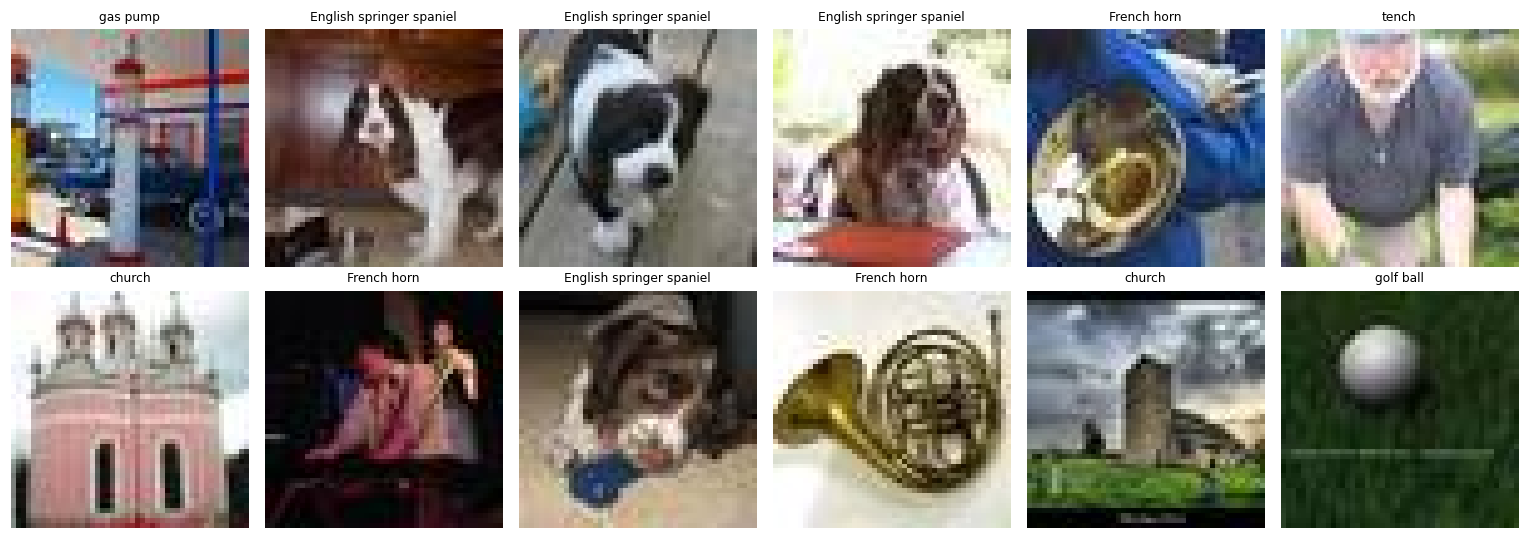

In [3]:
sample = rng.choice(n, 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes.ravel(), sample):
    ax.imshow(thumbs[i])
    ax.set_title(class_names[y[i]], fontsize=8)
    ax.axis("off")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/ic_sample_photos.png", bbox_inches="tight")
plt.show()

## 1. The obvious approach, and why it fails

A photo is a grid of pixels, so flatten it and cluster the pixel values. That is exactly what we
did to compress the Saryan painting. Each thumbnail is 48 x 48 x 3, so every photo becomes a
point in **6912 dimensions**. We know the true answer is ten groups, so we ask for ten.

In [4]:
pixels = thumbs.reshape(n, -1).astype(np.float32) / 255.0

# a slightly smarter classic baseline: how much of each color the photo contains
colour_hist = np.stack([
    np.histogramdd(t.reshape(-1, 3), bins=(4, 4, 4), range=((0, 255), (0, 255), (0, 255)))[0].ravel()
    for t in thumbs
])
colour_hist /= colour_hist.sum(axis=1, keepdims=True)

K = 10
baselines = {"raw pixels (6912 dims)": pixels, "color histogram (64 dims)": colour_hist}
for name, F in baselines.items():
    lab = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(F)
    print(f"{name:28s} ARI {adjusted_rand_score(y, lab):.3f}   "
          f"AMI {adjusted_mutual_info_score(y, lab):.3f}")

raw pixels (6912 dims)       ARI 0.048   AMI 0.100


color histogram (64 dims)    ARI 0.042   AMI 0.092


An ARI of about **0.05**. Chance is 0.0. This is not a near miss, it is a total failure, and it
is worth being precise about why, because the reason is not "k-means is weak".

**Pixel 1234 is not a feature.** Two photographs of the same dog, one a step to the left, share
almost no pixel values at the same coordinates. Meanwhile a photo of a golf ball on grass and a
photo of a church on grass agree strongly, because most of both images is green. Euclidean
distance between raw pixels measures *how similar two images look as grids of color*, and that
has close to nothing to do with what is in them.

The color histogram is smarter --- it at least ignores position --- and it scores no better. The
problem is not the arrangement of the features. It is that color is not the thing we care about.

## 2. Borrowing a representation

So we need features where distance means "shows a similar thing". Building those from scratch is
chapters 6 and 9 of this course. For today we **borrow** them.

**CLIP** is a model trained on a very large number of (image, caption) pairs, with one objective:
put an image and its own caption close together in a shared 512-dimensional space, and everything
else far apart. To learn that, it has to encode what an image is *of*. We are using it purely as
a black box: photo in, 512 numbers out.

Two consequences we will use:

- photos of similar things land near each other, which is all clustering needs,
- **text goes into the same space**, so an English word also has a vector, and we can ask which
  word a group of photos is closest to. That is how the clusters will name themselves.

In [5]:
print(f"embeddings   : {X.shape}")
norms = np.linalg.norm(X, axis=1)
print(f"vector length: mean {norms.mean():.2f}, std {norms.std():.2f} "
      f"(range {norms.min():.2f} to {norms.max():.2f})")

embeddings   : (2000, 512)
vector length: mean 10.53, std 0.54 (range 8.56 to 12.76)


### Should we normalize?

These vectors are compared with **cosine similarity** by design: what CLIP was trained to control
is the *angle* between an image and its caption, not the length. The standard move is to divide
every vector by its length, putting them all on the unit sphere, after which Euclidean distance
is a monotone function of cosine distance and k-means becomes spherical k-means.

That is the theory. Notice the numbers above before applying it: the lengths are already almost
constant. So measure instead of assuming, exactly as with the satellite bands.

In [6]:
Xn = X / np.linalg.norm(X, axis=1, keepdims=True)

for name, F in [("as-is", X), ("L2-normalized", Xn)]:
    lab = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(F)
    print(f"{name:16s} ARI {adjusted_rand_score(y, lab):.3f}")

as-is            ARI 0.938


L2-normalized    ARI 0.939


Barely a difference, and the reason is in the spread: the lengths vary by about 5 % around their
mean, so normalizing moves the points hardly at all. It is still the right default --- on
embeddings whose norms *do* vary it matters a great deal, and it costs one line --- but on this
data it is a formality rather than a fix. We keep the normalized version.

## 3. How many clusters?

We happen to know the answer is ten. Pretend we do not, and ask the usual two questions.

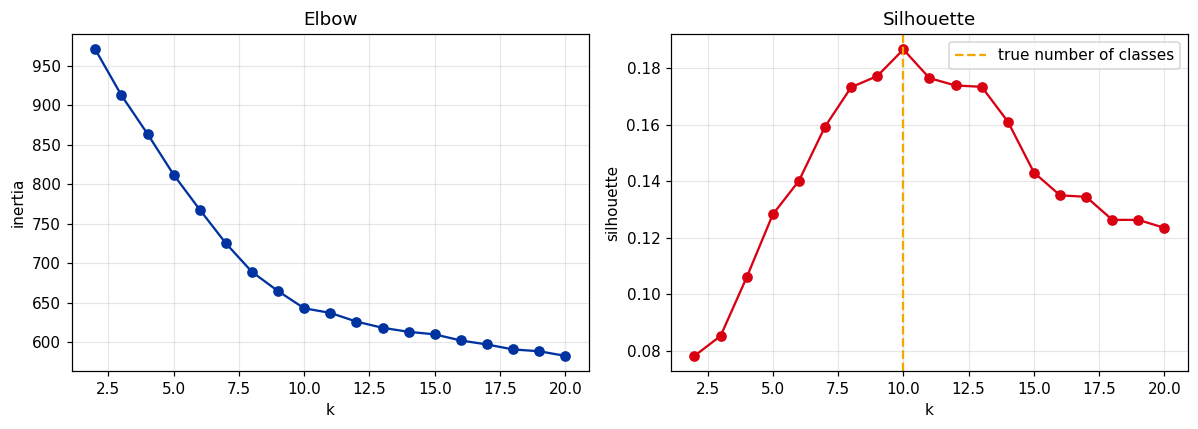

silhouette is highest at k = 10 (value 0.187)


In [7]:
k_values = list(range(2, 21))
inertia, silhouette = [], []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=5, random_state=SEED).fit(Xn)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(Xn, km.labels_, sample_size=2000, random_state=SEED))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_values, inertia, "o-", color=ARM_BLUE)
axes[0].set(xlabel="k", ylabel="inertia", title="Elbow")
axes[1].plot(k_values, silhouette, "o-", color=ARM_RED)
axes[1].axvline(10, color=ARM_ORANGE, ls="--", lw=1.5, label="true number of classes")
axes[1].set(xlabel="k", ylabel="silhouette", title="Silhouette")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/ic_elbow_silhouette.png", bbox_inches="tight")
plt.show()

best_k = k_values[int(np.argmax(silhouette))]
print(f"silhouette is highest at k = {best_k} (value {max(silhouette):.3f})")

The silhouette peaks essentially at the truth --- which is a striking change from the Sevan
practical, where it insisted on `k=2` and was badly wrong.

But look at the **value**: about 0.19. On the satellite data the silhouette at its peak was
nearly 0.7, and that partition was far worse. A silhouette of 0.19 sounds like "barely any
structure at all".

It is the curse of dimensionality from the lecture, in the flesh. In 512 dimensions every point
is far from every other point, so the gap between "distance to my own cluster" and "distance to
the nearest other cluster" is small in relative terms even when the grouping is perfect.
**Absolute silhouette values are not comparable between problems.** Its *shape* across `k` is
informative here; its height is not.

In [8]:
K = 10
km = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(Xn)
labels = km.labels_
print(f"cluster sizes: {np.bincount(labels)}")

cluster sizes: [209 189 197 198 189 197 197 193 202 229]


## 4. Let the clusters name themselves

In the Sevan practical, naming a cluster meant reading its mean spectrum and deciding by hand
what kind of ground it was. Here we can do better, because text lives in the same space.

Take a cluster's centre, and find which of our 40 candidate words has the closest vector. The
vocabulary deliberately contains far more words than there are classes --- cat, bicycle, pizza,
helicopter and so on --- so this is a genuine search, not a ten-way multiple choice with the
answer already in it.

In [9]:
Tn = T / np.linalg.norm(T, axis=1, keepdims=True)

cluster_names, naming = {}, []
for c in range(K):
    centre = Xn[labels == c].mean(axis=0)
    centre /= np.linalg.norm(centre)
    sims = Tn @ centre
    top = np.argsort(-sims)[:3]
    cluster_names[c] = vocabulary[top[0]]
    naming.append({
        "cluster": c,
        "size": int((labels == c).sum()),
        "name from text": vocabulary[top[0]],
        "similarity": float(sims[top[0]]),
        "runner-up": vocabulary[top[1]],
        "third": vocabulary[top[2]],
    })

print(pd.DataFrame(naming).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

 cluster  size           name from text  similarity  runner-up      third
       0   209          cassette player       0.336     camera  telephone
       1   189                 gas pump       0.364  telephone motorcycle
       2   197                    tench       0.361       boat      horse
       3   198 English springer spaniel       0.356      horse        cat
       4   189                parachute       0.338 helicopter   airplane
       5   197              French horn       0.363     violin     guitar
       6   197            garbage truck       0.363    tractor      train
       7   193                golf ball       0.349  parachute   umbrella
       8   202                   church       0.346      clock skyscraper
       9   229                chain saw       0.348    tractor     camera


Ten clusters, ten names, and nobody looked at a label to get them.

**The runner-ups are the interesting column.** They are not random: they are what the cluster
would be called if its first choice were taken away, and they read like a description of what
the photographs actually contain. A church is next-most a clock, because church towers have
clock faces in them. A golf ball is next-most a parachute --- both are white, round and
dome-shaped against an open background. A chain saw sits next to a tractor, a French horn next
to a violin, a fish next to a boat.

That is a real property of the space rather than a coincidence, and it is the clearest picture
you will get of what "distance" means once the features are learned rather than raw.

## 5. The map

512 dimensions do not fit on a screen, so we project to two. **This is the next lecture's
subject** --- for now, treat t-SNE as a black box that tries to keep points that were close in
512-D close in 2-D.

Note how badly a *linear* projection does at this: two principal components capture only a small
fraction of the variance, which is precisely why the dimensionality-reduction chapter exists.

In [10]:
pca = PCA(n_components=2, random_state=SEED).fit(Xn)
print(f"PCA: the first two components explain {pca.explained_variance_ratio_.sum():.1%} "
      f"of the variance")

Z = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30).fit_transform(Xn)
print(f"t-SNE projection: {Z.shape}")

PCA: the first two components explain 15.5% of the variance


t-SNE projection: (2000, 2)


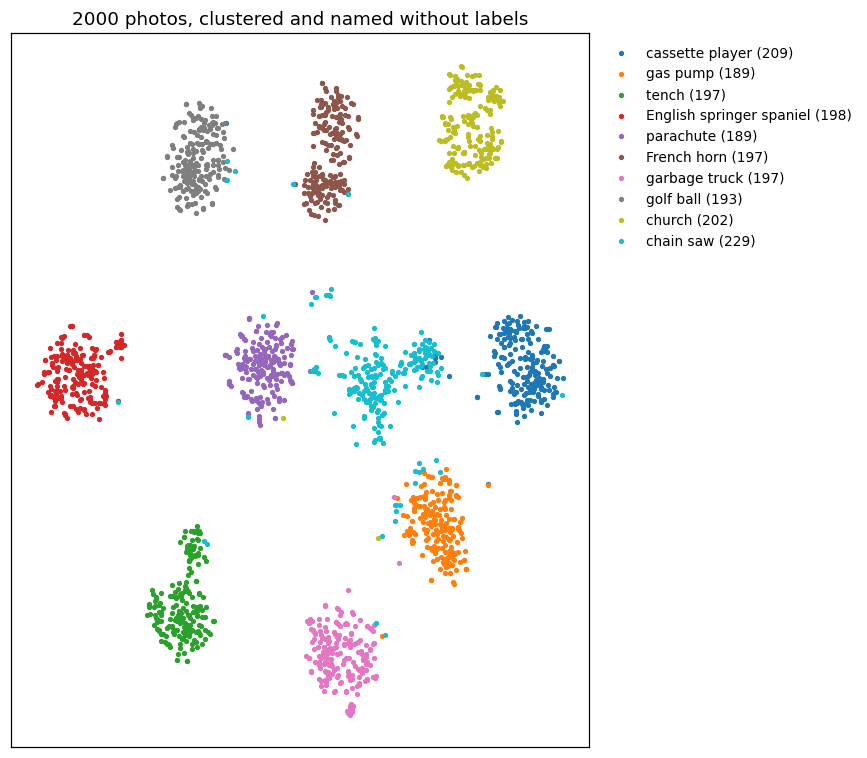

In [11]:
palette = plt.get_cmap("tab10")(np.arange(K))
fig, ax = plt.subplots(figsize=(8, 7))
for c in range(K):
    m = labels == c
    ax.scatter(Z[m, 0], Z[m, 1], s=6, color=palette[c], label=f"{cluster_names[c]} ({m.sum()})")
ax.set(title="2000 photos, clustered and named without labels", xticks=[], yticks=[])
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/ic_tsne_map.png", bbox_inches="tight")
plt.show()

Static, that is a nice picture. The useful version is one you can **hover**, so you can ask any
dot what photo it is --- especially the dots sitting in the wrong neighbourhood.

We write it as a single self-contained HTML file: the plotly library is inlined and every
thumbnail is embedded as a data URI, so the file works offline and can be sent to anyone.

In [12]:
def data_uri(i):
    raw = blob[offsets[i]:offsets[i + 1]].tobytes()
    return "data:image/jpeg;base64," + base64.b64encode(raw).decode("ascii")


figure = go.Figure()
for c in range(K):
    m = np.where(labels == c)[0]
    figure.add_trace(go.Scattergl(
        x=Z[m, 0], y=Z[m, 1],
        mode="markers",
        name=f"{cluster_names[c]} ({len(m)})",
        marker=dict(size=7, opacity=0.85, line=dict(width=0)),
        customdata=[[data_uri(i), class_names[y[i]]] for i in m],
        hovertemplate="<b>%{customdata[1]}</b><extra></extra>",
    ))
figure.update_layout(
    title="2000 photos grouped by CLIP embedding, k-means k=10 (hover a point to see it)",
    xaxis=dict(visible=False), yaxis=dict(visible=False),
    plot_bgcolor="white", width=1000, height=760,
    legend=dict(title="cluster name, chosen from text"),
)

HOVER_JS = """
<div id="thumbbox" style="position:fixed;display:none;pointer-events:none;z-index:9999;
     border:2px solid #333;background:#fff;padding:3px;border-radius:4px;
     box-shadow:0 2px 10px rgba(0,0,0,.35)">
  <img id="thumbimg" width="112" height="112" style="display:block">
</div>
<script>
(function () {
  var gd = document.getElementById('clustermap');
  var box = document.getElementById('thumbbox'), im = document.getElementById('thumbimg');
  gd.on('plotly_hover', function (ev) {
    var p = ev.points[0];
    if (!p.customdata) { return; }
    im.src = p.customdata[0];
    box.style.display = 'block';
    var x = ev.event.clientX + 18, yy = ev.event.clientY + 18;
    if (x + 130 > window.innerWidth)  { x = ev.event.clientX - 140; }
    if (yy + 130 > window.innerHeight) { yy = ev.event.clientY - 140; }
    box.style.left = x + 'px';
    box.style.top = yy + 'px';
  });
  gd.on('plotly_unhover', function () { box.style.display = 'none'; });
})();
</script>
"""

html = figure.to_html(div_id="clustermap", include_plotlyjs="inline", full_html=True)
html = html.replace("</body>", HOVER_JS + "</body>")
html_path = f"{OUT_DIR}/image_clusters.html"
with open(html_path, "w", encoding="utf-8") as fh:
    fh.write(html)
print(f"wrote {html_path}  ({os.path.getsize(html_path)/1e6:.1f} MB, self-contained)")

wrote out/image_clusters.html  (8.5 MB, self-contained)


Open `out/image_clusters.html` in a browser. Hover the boundary between two clusters and you can
watch the model change its mind: photographs that are genuinely ambiguous sit exactly there.

## 6. Scoring it

Now the labels. Same two chance-adjusted metrics as the satellite practical, and the comparison
that matters is not against a perfect score but against what we got from pixels.

In [13]:
rows = []
for name, F in [("raw pixels", pixels),
                ("color histogram", colour_hist),
                ("CLIP embedding", Xn)]:
    lab = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(F)
    rows.append({"representation": name,
                 "dims": F.shape[1],
                 "ARI": adjusted_rand_score(y, lab),
                 "AMI": adjusted_mutual_info_score(y, lab)})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

 representation  dims   ARI   AMI
     raw pixels  6912 0.048 0.100
color histogram    64 0.042 0.092
 CLIP embedding   512 0.939 0.944


**Same algorithm. Same `k`. Same photographs. Nothing changed except the numbers used to
describe each image, and the score went up roughly twentyfold.**

Which classes did it confuse?

In [14]:
ct = pd.crosstab(pd.Series([class_names[i] for i in y], name="true class"),
                 pd.Series([cluster_names[c] for c in labels], name="cluster name"))
print(ct.to_string())

cluster name              English springer spaniel  French horn  cassette player  chain saw  church  garbage truck  gas pump  golf ball  parachute  tench
true class                                                                                                                                               
English springer spaniel                       198            0                0          2       0              0         0          0          0      0
French horn                                      0          197                1          2       0              0         0          0          0      0
cassette player                                  0            0              196          4       0              0         0          0          0      0
chain saw                                        0            0                9        190       0              1         0          0          0      0
church                                           0            0             

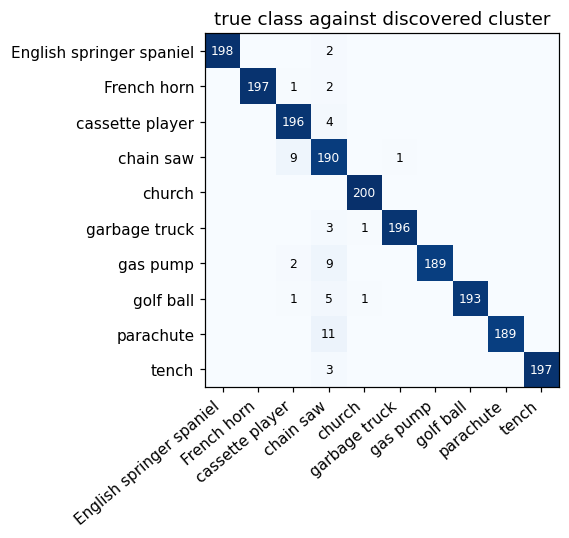

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(ct.values, cmap="Blues")
ax.set_xticks(range(ct.shape[1]), ct.columns, rotation=40, ha="right")
ax.set_yticks(range(ct.shape[0]), ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=8,
                    color="white" if v > ct.values.max() / 2 else "black")
ax.set_title("true class against discovered cluster")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/ic_confusion.png", bbox_inches="tight")
plt.show()

Almost diagonal. The interesting exception is one cluster that runs wide: it holds its own class
plus a handful of strays from nearly every other one.

In [16]:
strays = ct.sum(axis=0) - ct.max(axis=0)
print("photos in each cluster that do not belong to its majority class:")
print(strays.sort_values(ascending=False).to_string())

photos in each cluster that do not belong to its majority class:
cluster name
chain saw                   39
cassette player             13
church                       2
garbage truck                1
English springer spaniel     0
French horn                  0
gas pump                     0
golf ball                    0
parachute                    0
tench                        0


That cluster is the **junk drawer**, and its existence is structural rather than accidental.
k-means must place every point somewhere; it has no way to say *this photograph does not belong
to anything*. The odd, dark, cluttered and badly framed images have to go into some cluster, and
they end up together in whichever one is loosest, because they resemble each other in being
unlike everything else.

This is the same limitation the satellite practical ran into from the other side, where DBSCAN
could label noise and k-means could not. If flagging the misfits mattered here, that is the tool
to reach for.

## Conclusion

- Clustering **photographs** by their pixels does not work, and no amount of tuning `k` or
  swapping algorithms would have rescued it. ARI 0.05.
- Clustering the same photographs by a **learned embedding** works almost perfectly. ARI 0.94,
  with the algorithm, the metric and the number of clusters all unchanged.
- Because CLIP puts text in the same space, the clusters **named themselves** from a 40-word
  vocabulary, correctly, with no labels involved. The near-misses (church/clock,
  golf ball/parachute) show what the space considers similar.
- The silhouette picked the right `k` here and the wrong one at Sevan, and its absolute value was
  *lower* on the better partition. Internal metrics are shape diagnostics, not scores.
- One cluster always ends up as a junk drawer, because k-means cannot decline to assign a point.

The broader point, and the one to carry out of this chapter: across three practicals the
algorithm barely changed. What changed was the **representation** --- pixels, then engineered
spectral indices, then a learned embedding --- and it decided the outcome every time. Clustering
is only ever as good as the space you do it in.